In [1]:
from pathlib import Path
import sys

import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "promo_analysis"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

from jd_project.data import load_raw_tables

In [2]:
tables = load_raw_tables(RAW_DIR)

orders_df = tables["orders"]
delivery_df = tables["delivery"]
inventory_df = tables["inventory"]
network_df = tables["network"]
users_df = tables["users"]
skus_df = tables["skus"]

========== Promo DataFrame ==========
Shape: (549989, 32)

========== Reconciliation Check ==========
count    549989.0
mean         -0.0
std           0.0
min          -0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: discount_reconcile_diff, dtype: Float64
Share of rows with reconciliation mismatch > 1e-06: 0.0000%

========== Discount Rate vs Quantity ==========
Pearson correlation : 0.0483
Spearman correlation: 0.1946

========== Discount Bucket Summary ==========
  discount_rate_bin  order_lines  total_units  avg_units_per_line  median_units_per_line  avg_discount_rate
0                 0        73478        81560            1.109992                    1.0           0.000000
1            (0,5%]        11919        14244            1.195067                    1.0           0.026986
2           (5,10%]        18304        20547            1.122542                    1.0           0.074558
3          (10,20%]        66640        74146            1.112

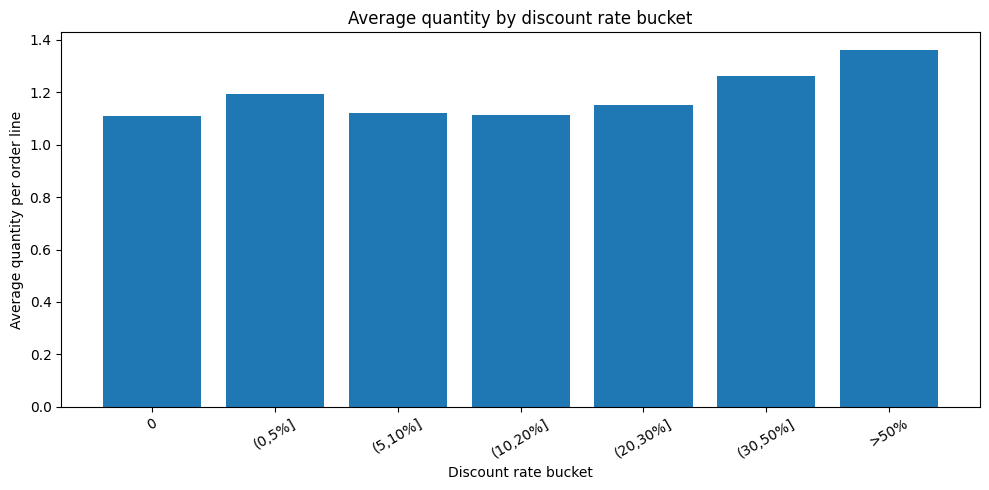

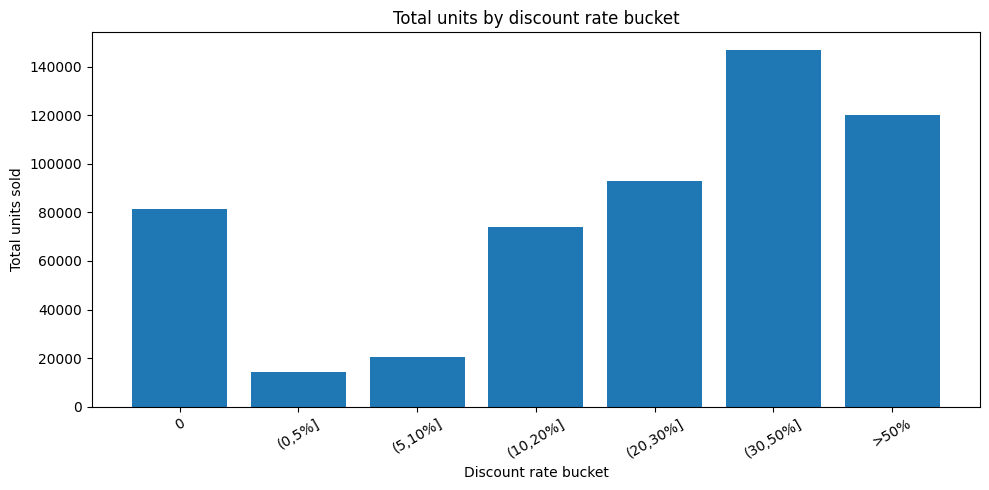

========== Discount Frequency ==========
                discount_type  used_order_lines  used_ratio
0    direct_discount_per_unit            309703    0.563108
1  quantity_discount_per_unit            129926    0.236234
3    coupon_discount_per_unit            115226    0.209506
2    bundle_discount_per_unit              8284    0.015062

========== Discount Amount Contribution ==========
                discount_type  total_discount_amount  avg_discount_amount_per_used_line
0    direct_discount_per_unit            13058231.45                          42.163723
1  quantity_discount_per_unit             6077339.42                          46.775391
3    coupon_discount_per_unit             1823905.55                          15.828941
2    bundle_discount_per_unit              423383.58                          51.108592

========== Discount Overview ==========
                discount_type  used_order_lines  used_ratio  total_discount_amount  avg_discount_amount_per_used_line
0    dir

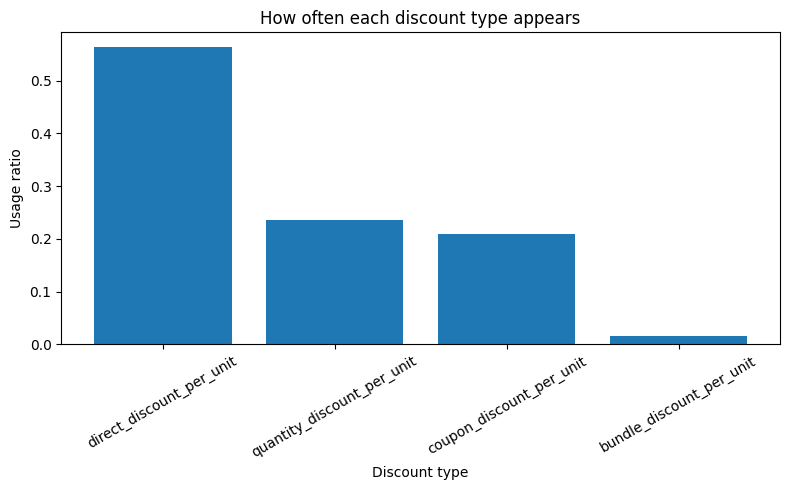

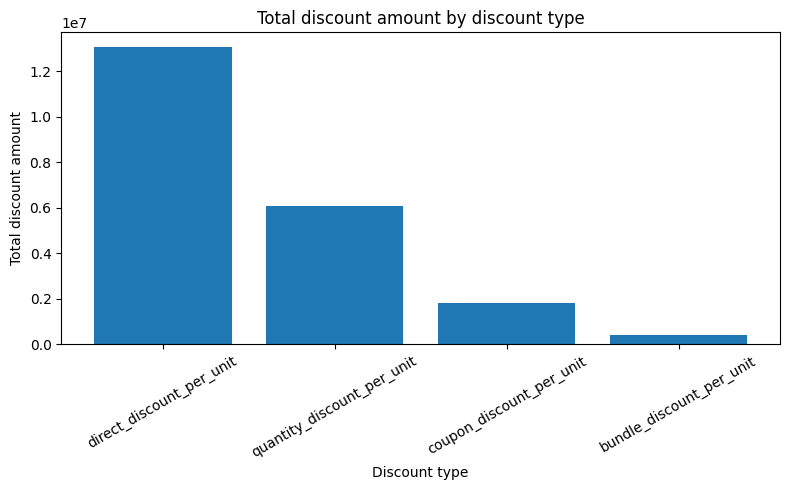

========== Seller Type Summary ==========
  seller_type  order_lines  total_units  avg_units_per_line  avg_original_price  avg_final_price  avg_discount_rate  median_discount_rate  promo_line_ratio
0          1P       275468       338958             1.23048          121.643754        85.135582           0.302658              0.268456          0.872544
1          3P       274521       330197            1.202811           83.918373        57.962828           0.273512              0.256410          0.546734

========== Discount Usage by Seller Type ==========
  seller_type               discount_type  usage_ratio  used_order_lines
0          1P    direct_discount_per_unit     0.710478            195714
1          1P  quantity_discount_per_unit     0.328372             90456
2          1P    bundle_discount_per_unit     0.025121              6920
3          1P    coupon_discount_per_unit     0.237857             65522
4          3P    direct_discount_per_unit     0.415229            113989

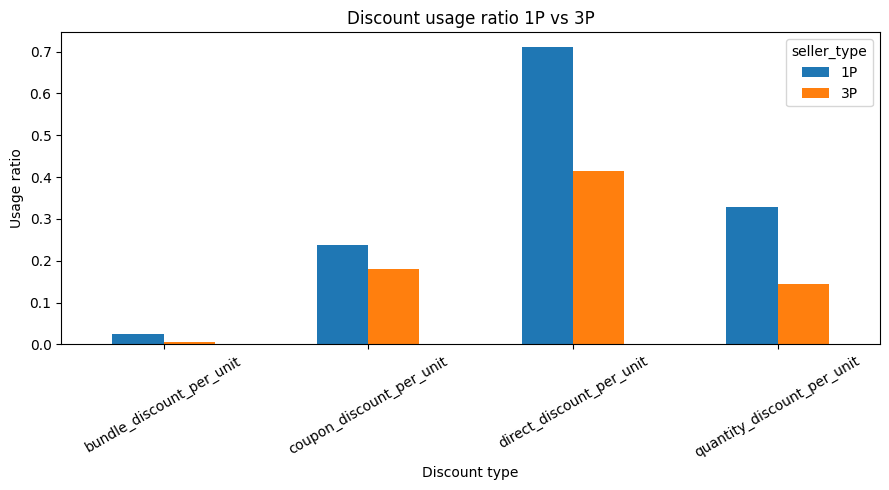

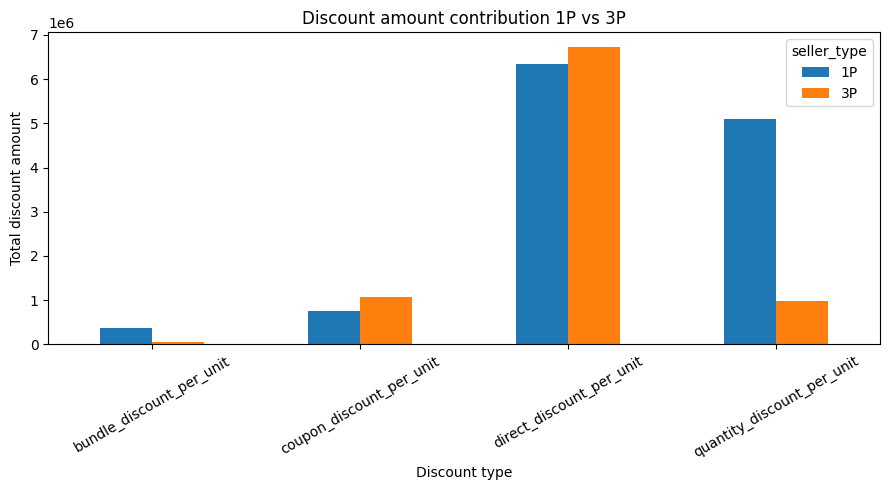

========== Final Summary Table ==========
                discount_type  used_order_lines  used_ratio  total_discount_amount  avg_discount_amount_per_used_line
0    direct_discount_per_unit            309703      0.5631            13058231.45                              42.16
1  quantity_discount_per_unit            129926      0.2362             6077339.42                              46.78
2    coupon_discount_per_unit            115226      0.2095             1823905.55                              15.83
3    bundle_discount_per_unit              8284      0.0151              423383.58                              51.11

========== Promoted Lines Only: Discount Bucket Summary ==========
  discount_rate_bin  order_lines  total_units  avg_units_per_line  median_units_per_line  avg_discount_rate
0                 0            0            0                <NA>                   <NA>                NaN
1            (0,5%]        11919        14244            1.195067                   

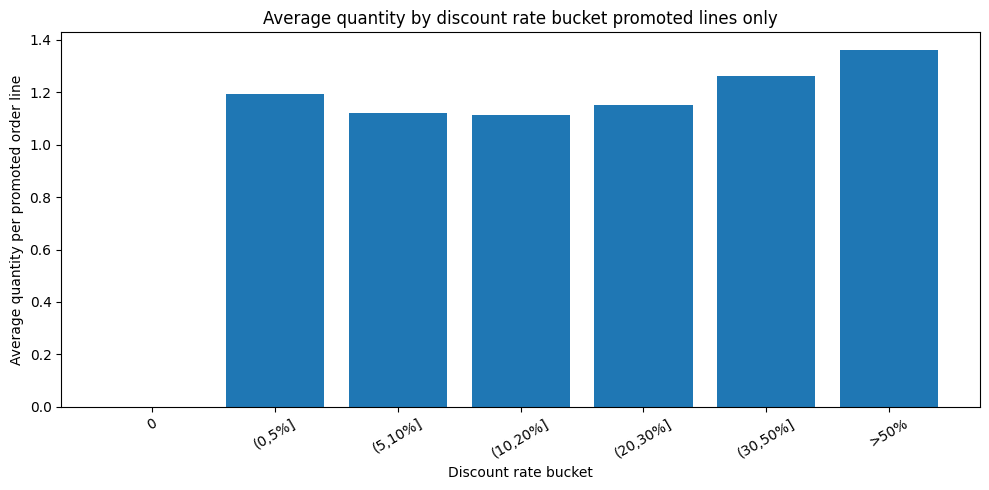

In [3]:
from jd_project.promo_analysis import run_promo_analysis

results = run_promo_analysis(
    orders_df,
    show_plots=True,
    verbose=True,
    save_dir=PROCESSED_DIR,
)

In [4]:
# Save all results
for name, df in results.items():
    if isinstance(df, pd.DataFrame):
        df.to_csv(PROCESSED_DIR / f"{name}.csv", index=False)

# Save Excel version
with pd.ExcelWriter(PROCESSED_DIR / "promo_analysis_results.xlsx") as writer:
    for name, df in results.items():
        if isinstance(df, pd.DataFrame):
            df.to_excel(writer, sheet_name=name[:31], index=False)

ModuleNotFoundError: No module named 'openpyxl'

In [ ]:
import importlib
import jd_project.promo_analysis

# Reload updated function
importlib.reload(jd_project.promo_analysis)

from jd_project.promo_analysis import run_promo_analysis

# Run analysis + save plots + save tables
results = run_promo_analysis(
    orders_df,
    show_plots=True,
    verbose=True,
    save_dir=PROCESSED_DIR
)